In [27]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.utils.data import Subset
import pandas as pd
import os
import cv2
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
# --- KONFIGURACJA ---

DATASET_POINTS = 600000
MAX_HEIGHT = 200     
DEBUG_SAVE_CSV = True 
SHOW_SAMPLES = 125     


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"{device}")

cuda


In [28]:
midas_utils = torch.hub.load("intel-isl/MiDaS", "transforms")
transform = midas_utils.small_transform
midas_base = torch.hub.load("intel-isl/MiDaS", "MiDaS_small")

Using cache found in C:\Users\kulak/.cache\torch\hub\intel-isl_MiDaS_master
Using cache found in C:\Users\kulak/.cache\torch\hub\intel-isl_MiDaS_master
Using cache found in C:\Users\kulak/.cache\torch\hub\rwightman_gen-efficientnet-pytorch_master


Loading weights:  None


In [29]:
class DroneHeightDataset(Dataset):
    def __init__(self, csv_file, img_dir, transform=None):
        self.data = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_name = self.data.iloc[idx]['img']
        img_path = os.path.join(self.img_dir, img_name)
        
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
       # W klasie DroneHeightDataset
        altitude = torch.tensor(self.data.iloc[idx]['alt'], dtype=torch.float32) / MAX_HEIGHT

        if self.transform:
            # Transformacja MiDaS zwraca [1, 3, H, W]
            image = self.transform(image)
            # Usuwamy ten pierwszy wymiar, żeby zostało [3, H, W]
            if len(image.shape) == 4:
                image = image.squeeze(0)

        return image, altitude

In [30]:
import os
import torch
from torch.utils.data import DataLoader, Subset

# ==========================================================
# --- KONFIGURACJA GLOBALNA (Zmieniaj tutaj) ---
# ==========================================================
MAX_HEIGHT = 200              # Zakres wysokości drona (0-200m)
BATCH_SIZE = 8              # Ilość zdjęć przetwarzanych naraz
NUM_EPOCHS = 1
TRAIN_SAMPLES_PER_EPOCH = 10000000000 # Ile losowych zdjęć do nauki w jednej epoce
VAL_SAMPLES_PER_EPOCH = 1000000  # Ile zdjęć do testu (walidacji) po epoce
# ==========================================================

root = r"Z:\Documents\Programs\AirTrace\sim\Dataset_balanced"

# 1. Inicjalizacja pełnych zbiorów danych
train_dataset = DroneHeightDataset(
    csv_file=os.path.join(root, "labels", "train.csv"),
    img_dir=os.path.join(root, "images", "train"),
    transform=transform
)

val_dataset = DroneHeightDataset(
    csv_file=os.path.join(root, "labels", "val.csv"),
    img_dir=os.path.join(root, "images", "val"),
    transform=transform
)

test_dataset = DroneHeightDataset(
    csv_file=os.path.join(root, "labels", "test.csv"),
    img_dir=os.path.join(root, "images", "test"),
    transform=transform
)

# 2. Losowanie indeksów (mieszanie wysokości: niskie vs wysokie)
train_indices = torch.randperm(len(train_dataset))[:TRAIN_SAMPLES_PER_EPOCH].tolist()
val_indices = torch.randperm(len(val_dataset))[:VAL_SAMPLES_PER_EPOCH].tolist()

# 3. Tworzenie Loaderów
train_loader = DataLoader(
    Subset(train_dataset, train_indices), 
    batch_size=BATCH_SIZE, 
    shuffle=True
)

val_loader = DataLoader(
    Subset(val_dataset, val_indices), 
    batch_size=BATCH_SIZE, 
    shuffle=False # Przy walidacji shuffle nie jest potrzebne
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False
)

print(f"📊 DATASET READY")
print(f"--> Trening: {len(train_loader.dataset)} zdjęć (losowych)")
print(f"--> Walidacja: {len(val_loader.dataset)} zdjęć (losowych)")
print(f"--> Test: {len(test_dataset)} zdjęć (całość)")

📊 DATASET READY
--> Trening: 3156 zdjęć (losowych)
--> Walidacja: 394 zdjęć (losowych)
--> Test: 395 zdjęć (całość)


In [ ]:
import torch
import torch.nn as nn

class DroneHeightModel(nn.Module):
    def __init__(self, backbone_model, max_height=200):
        super(DroneHeightModel, self).__init__()
        self.backbone = backbone_model
        self.max_height = max_height
        
        # AdaptiveAvgPool sprowadza mapy cech do rozmiaru 1x1, zachowując kanały
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        
  
        self.fc = nn.Sequential(
            nn.Linear(1, 512),      
            nn.BatchNorm1d(512),     
            nn.ReLU(),
            nn.Dropout(0.3),     
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, 1),
            nn.Sigmoid()            
        )

    def forward(self, x):
        f = self.backbone(x) 
        
        # 2. Upewniamy się, że mamy wymiar kanałów: [Batch, 1, H, W]
        if len(f.shape) == 3:
            f = f.unsqueeze(1)
            
        # 3. Pooling i spłaszczenie: [Batch, Channels]
        pooled = self.pool(f)
        flat = torch.flatten(pooled, 1)
        
        # 4. Przejście przez głowicę i skalowanie do metrów
        # Ponieważ fc kończy się Sigmoidem (0-1), mnożymy przez max_height
        return self.fc(flat) 

# --- WYWOŁANIE I INICJALIZACJA ---

# 1. Ustawienie urządzenia
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. Stworzenie instancji (zakładając, że midas_base już masz wczytany)
model = DroneHeightModel(backbone_model=midas_base, max_height=200)

# 3. Przeniesienie na GPU/CPU
model.to(device)

print(f"Model gotowy do pracy na: {device}")

Model gotowy do pracy na: cuda


In [32]:
# 1. Tworzymy obraz
test_input = torch.randn(1, 3, 256, 256).to(device)

# 2. KLUCZ: Przełączamy model w tryb testowania
model.eval() 

with torch.no_grad():
     out = model(test_input)
     print(f"Udało się! Wynik modelu dla 1 zdjęcia: {out.item():.2f} metrów")

Udało się! Wynik modelu dla 1 zdjęcia: 1.00 metrów


In [33]:
import torch.optim as optim

# 1. Funkcja straty (Loss Function)
# MSE (Mean Squared Error) to standard dla regresji (przewidywania liczb takich jak wysokość)
criterion = torch.nn.MSELoss()

# 2. Optymalizator (Optimizer)
# Używamy Adama, bo jest bardzo skuteczny i sam dobiera tempo uczenia.
# lr=1e-4 (czyli 0.0001) to bezpieczna wartość dla modelu MiDaS.
optimizer = optim.Adam(model.parameters(), lr=1e-3)

print("Optimizer i Criterion (funkcja straty) są gotowe!")

Optimizer i Criterion (funkcja straty) są gotowe!


In [34]:
import os
import pandas as pd
import torch
import torchvision.utils as vutils
from tqdm.auto import tqdm

# --- KONFIGURACJA ZAPISU OBRAZÓW ---
SAVE_DEBUG_IMAGES = True
NUM_IMAGES_TO_SAVE = 20  # Ile zdjęć zapisać na każdą epokę walidacji
DEBUG_IMG_DIR = "debug_outputs"
os.makedirs(DEBUG_IMG_DIR, exist_ok=True)

history = {'train_mae': [], 'val_mae': []}
best_val_loss = float('inf')

for epoch in range(NUM_EPOCHS):
    # 1. Przygotowanie danych (bez zmian)
    train_idx = torch.randperm(len(train_dataset))[:TRAIN_SAMPLES_PER_EPOCH].tolist()
    epoch_train_loader = DataLoader(Subset(train_dataset, train_idx), batch_size=BATCH_SIZE, shuffle=True)
    val_idx = torch.randperm(len(val_dataset))[:VAL_SAMPLES_PER_EPOCH].tolist()
    epoch_val_loader = DataLoader(Subset(val_dataset, val_idx), batch_size=BATCH_SIZE, shuffle=True)

    # 2. Faza Treningu (bez zmian)
    model.train()
    running_train_mae = 0.0
    tbar = tqdm(epoch_train_loader, desc=f"Ep {epoch+1}/{NUM_EPOCHS} [Trening]")
    for imgs, alts in tbar:
        imgs, alts = imgs.to(device), alts.to(device).unsqueeze(1)
        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out, alts)
        loss.backward()
        optimizer.step()
        mae = torch.abs(out - alts).mean().item()
        running_train_mae += mae * imgs.size(0)
        tbar.set_postfix(mae=f"{mae:.2f}m")

    avg_train_mae = running_train_mae / TRAIN_SAMPLES_PER_EPOCH
    history['train_mae'].append(avg_train_mae)


    # 3. Faza Walidacji + Zapis zdjęć
    model.eval()
    epoch_results = []
    epoch_img_dir = os.path.join(DEBUG_IMG_DIR, f"epoch_{epoch+1}")
    if SAVE_DEBUG_IMAGES: os.makedirs(epoch_img_dir, exist_ok=True)
    
    saved_count = 0
    print(f"\n--- SZCZEGÓŁOWE WYNIKI WALIDACJI (Epoka {epoch+1}) ---") # Nagłówek dla czytelności
    
    with torch.no_grad():
        vbar = tqdm(epoch_val_loader, desc=f"Ep {epoch+1} [Walidacja]", leave=False)
        for imgs, alts in vbar:
            imgs_device = imgs.to(device)
            alts_device = alts.to(device).unsqueeze(1)
            out = model(imgs_device)
            
            preds = out.cpu().numpy().flatten()
            reals = alts_device.cpu().numpy().flatten()
            
            for i in range(len(preds)):
                p = preds[i] * MAX_HEIGHT
                r = reals[i] * MAX_HEIGHT
                error = abs(p - r)
                
                # WYŚWIETLANIE WYNIKU DLA KAŻDEGO ZDJĘCIA
                print(f"Zdjęcie #{saved_count:03d} | Rzeczywista: {r:6.2f}m | AI: {p:6.2f}m | Błąd: {error:6.2f}m")
                
                # Reszta Twojego kodu zapisu zdjęć...
                img_filename = f"sample_{saved_count}_R{r:.1f}_P{p:.1f}.jpg"
                if SAVE_DEBUG_IMAGES and saved_count < NUM_IMAGES_TO_SAVE:
                    vutils.save_image(imgs[i], os.path.join(epoch_img_dir, img_filename))
                
                epoch_results.append({
                    'Image_Index': saved_count,
                    'Real_Height': r,
                    'AI_Prediction': p,
                    'Error': error,
                    'Image_Path': img_filename if saved_count < NUM_IMAGES_TO_SAVE else "Not Saved"
                })
                saved_count += 1
                

    # Logowanie i raport (bez zmian)
    df_results = pd.DataFrame(epoch_results)
    avg_val_mae = df_results['Error'].mean()
    history['val_mae'].append(avg_val_mae)
    df_results.to_csv(f"results_epoch_{epoch+1}.csv", index=False)

    print(f"\n📊 RAPORT EPOKI {epoch+1}")
    print(f"Train MAE: {avg_train_mae:.2f}m | Val MAE: {avg_val_mae:.2f}m")
    if avg_val_mae < best_val_loss:
        best_val_loss = avg_val_mae
        torch.save(model.state_dict(), "best_model.pth")
        print("⭐ Zapisano najlepszy model!")
    print(f"🖼️ Zapisano {min(saved_count, NUM_IMAGES_TO_SAVE)} zdjęć do: {epoch_img_dir}")
    print("-" * 60)

Ep 1/1 [Trening]:   0%|          | 0/395 [00:00<?, ?it/s]


--- SZCZEGÓŁOWE WYNIKI WALIDACJI (Epoka 1) ---


Ep 1 [Walidacja]:   0%|          | 0/50 [00:00<?, ?it/s]

Zdjęcie #000 | Rzeczywista: 142.01m | AI: 129.56m | Błąd:  12.45m
Zdjęcie #001 | Rzeczywista: 195.16m | AI: 158.95m | Błąd:  36.21m
Zdjęcie #002 | Rzeczywista: 151.79m | AI: 136.84m | Błąd:  14.94m
Zdjęcie #003 | Rzeczywista: 108.40m | AI: 104.77m | Błąd:   3.63m
Zdjęcie #004 | Rzeczywista: 196.61m | AI: 162.66m | Błąd:  33.96m
Zdjęcie #005 | Rzeczywista: 186.55m | AI: 153.19m | Błąd:  33.36m
Zdjęcie #006 | Rzeczywista:  18.02m | AI:   5.03m | Błąd:  12.99m
Zdjęcie #007 | Rzeczywista:  57.49m | AI:  57.98m | Błąd:   0.49m
Zdjęcie #008 | Rzeczywista:  89.90m | AI:  91.76m | Błąd:   1.86m
Zdjęcie #009 | Rzeczywista: 105.69m | AI: 103.56m | Błąd:   2.12m
Zdjęcie #010 | Rzeczywista: 175.45m | AI: 158.37m | Błąd:  17.09m
Zdjęcie #011 | Rzeczywista:  47.95m | AI:  39.72m | Błąd:   8.23m
Zdjęcie #012 | Rzeczywista: 119.99m | AI: 112.57m | Błąd:   7.42m
Zdjęcie #013 | Rzeczywista:  14.97m | AI:   5.03m | Błąd:   9.94m
Zdjęcie #014 | Rzeczywista: 158.03m | AI: 147.24m | Błąd:  10.79m
Zdjęcie #0

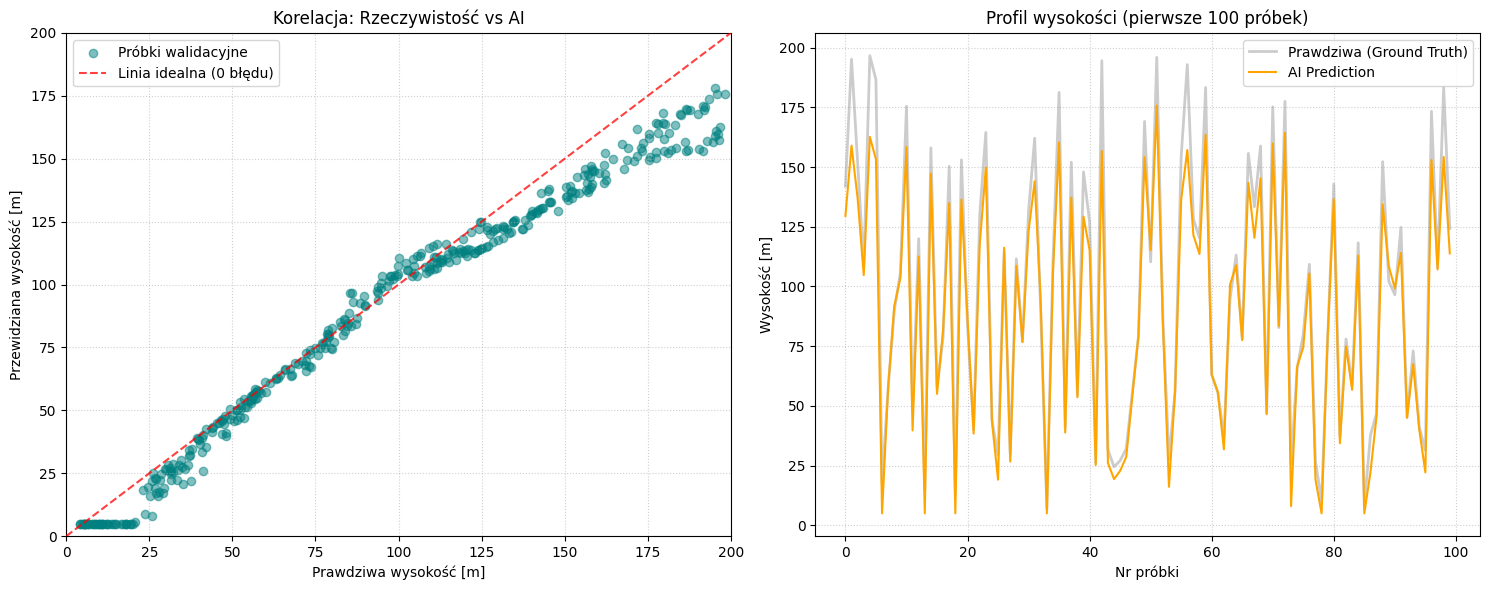

In [35]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_detailed_results(df_results):
    """
    df_results: DataFrame z kolumnami 'Real_Height', 'AI_Prediction'
    """
    plt.figure(figsize=(15, 6))

    # --- WYKRES 1: KORELACJA (Scatter Plot) ---
    plt.subplot(1, 2, 1)
    plt.scatter(df_results['Real_Height'], df_results['AI_Prediction'], alpha=0.5, color='teal', label='Próbki walidacyjne')
    
    # Linia idealna (y = x)
    lims = [0, MAX_HEIGHT]
    plt.plot(lims, lims, 'r--', alpha=0.75, zorder=3, label='Linia idealna (0 błędu)')
    
    plt.title('Korelacja: Rzeczywistość vs AI')
    plt.xlabel('Prawdziwa wysokość [m]')
    plt.ylabel('Przewidziana wysokość [m]')
    plt.xlim(0, MAX_HEIGHT)
    plt.ylim(0, MAX_HEIGHT)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend()

    # --- WYKRES 2: PORÓWNANIE PROFILU (First N samples) ---
    plt.subplot(1, 2, 2)
    n_samples = min(100, len(df_results))
    subset = df_results.iloc[:n_samples]
    
    plt.plot(subset['Real_Height'].values, 'gray', alpha=0.4, label='Prawdziwa (Ground Truth)', linewidth=2)
    plt.plot(subset['AI_Prediction'].values, 'orange', label='AI Prediction', linewidth=1.5)
    
    plt.title(f'Profil wysokości (pierwsze {n_samples} próbek)')
    plt.xlabel('Nr próbki')
    plt.ylabel('Wysokość [m]')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend()

    plt.tight_layout()
    plt.show()

# WYWOŁANIE:
# Zakładamy, że df_results to wyniki z ostatniej epoki (lub wczytane z CSV)
# df_results = pd.read_csv("results_epoch_10.csv") 
plot_detailed_results(df_results)

In [39]:
import cv2
import torch
import os
from tqdm import tqdm

# --- KONFIGURACJA ---
INPUT_VIDEO = "test_flight.mkv"
OUTPUT_VIDEO = "debug_result.mkv"
MODEL_PATH = "best_model_drone.pth"
MAX_HEIGHT = 200
DEBUG_STEP = 55

# 1. Ładowanie modelu
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")



model.to(device)
model.eval()

# 2. Otwarcie wideo
cap = cv2.VideoCapture(INPUT_VIDEO)
width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps    = int(cap.get(cv2.CAP_PROP_FPS))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

# Dostosowanie FPS dla wyjścia w trybie debug (żeby film nie leciał 10x za szybko)
debug_fps = fps // 1 if DEBUG_STEP == 1 else fps

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(OUTPUT_VIDEO, fourcc, debug_fps, (width, height))

# 3. Pętla z co 10-tą klatką
print(f"🎬 Debugowanie: Przetwarzam co {DEBUG_STEP} klatkę...")

frame_idx = 0
processed_count = 0

with torch.no_grad():
    # Pasek postępu uwzględnia skok klatek
    pbar = tqdm(total=total_frames // DEBUG_STEP if total_frames else None)
    
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        # SKOK: Przetwarzaj tylko klatki podzielne przez DEBUG_STEP
        if frame_idx % DEBUG_STEP == 0:
            img_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            
            # Ważne: Sprawdź czy transform jest zdefiniowany!
            input_tensor = transform(img_rgb).to(device)
            
            # Predykcja
            pred_alt = model(input_tensor).item()*MAX_HEIGHT
            
            # DEBUG: Wypisz pierwsze 5 wyników do konsoli, żeby sprawdzić czy to nie 0.000...
            if processed_count < 5:
                print(f"Klatka {frame_idx} -> Przewidziana wysokość: {pred_alt:.4f}m")

            # Rysowanie
            text = f"AI Altitude: {pred_alt:.1f}m"
            cv2.putText(frame, text, (53, 103), cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 0, 0), 5, cv2.LINE_AA)
            cv2.putText(frame, text, (50, 100), cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 255, 0), 3, cv2.LINE_AA)
            
            out.write(frame)
            pbar.update(1)
            processed_count += 1
            
        frame_idx += 1

cap.release()
out.release()
print(f"\n✅ Debug zakończony. Sprawdź plik: {OUTPUT_VIDEO}")

🎬 Debugowanie: Przetwarzam co 55 klatkę...


194it [00:32,  5.94it/s]
2it [00:00, 10.75it/s]

Klatka 0 -> Przewidziana wysokość: 5.0302m
Klatka 55 -> Przewidziana wysokość: 5.0302m


4it [00:00,  9.14it/s]

Klatka 110 -> Przewidziana wysokość: 5.0302m
Klatka 165 -> Przewidziana wysokość: 5.0302m


7it [00:00,  9.65it/s]

Klatka 220 -> Przewidziana wysokość: 5.0302m


177it [00:19,  8.43it/s]


✅ Debug zakończony. Sprawdź plik: debug_result.mkv
